In [1]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
import os
import pandas as pd
from datetime import timedelta
import matplotlib.dates as mdates

In [2]:
PATH_RADAR = '../../data/radar/'
PATH_FIG = '../figures/'

In [3]:
# Radar data
cloudnet_filename = []
for file in os.listdir(PATH_RADAR):
    if file.endswith(".nc"):
        cloudnet_filename.append(file)

i = 0        
radar = nc.Dataset(PATH_RADAR+cloudnet_filename[i])

aux_t = []
for h in radar['time']:
    aux_t.append( cloudnet_filename[i][:8] + ' ' + str(timedelta(hours=float(h))) )

dtime = pd.to_datetime(aux_t, format = "%Y%m%d %H:%M:%S" ) 

print(radar)

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4_CLASSIC data model, file format HDF5):
    Conventions: CF-1.8
    cloudnetpy_version: 1.29.4
    file_uuid: b58f94ab-8d9a-4ab1-9bba-ad43bd2e169d
    cloudnet_file_type: radar
    title: RPG-FMCW-94 cloud radar from Granada
    year: 2021
    month: 04
    day: 30
    location: Granada
    history: 2022-02-15 17:25:46 +00:00 - radar file created
    source: RPG-Radiometer Physics RPG-FMCW-94
    references: https://doi.org/10.21105/joss.02123
    dimensions(sizes): time(24010), range(380), chirp_sequence(4)
    variables(dimensions): int32 file_code(), int32 program_number(), int32 model_number(), float32 radar_frequency(), float32 antenna_separation(), float32 antenna_diameter(), float32 antenna_gain(), float32 half_power_beam_width(), int32 dual_polarization(), float32 sample_duration(), float32 latitude(), float32 longitude(), int32 calibration_interval(), float32 range(range), int32 number_of_spectral_samples(chirp_sequence), i

In [4]:
radar.variables

{'file_code': <class 'netCDF4._netCDF4.Variable'>
 int32 file_code()
     units: 1
     long_name: File code
     comment: Indicates the RPG software version.
 unlimited dimensions: 
 current shape = ()
 filling off,
 'program_number': <class 'netCDF4._netCDF4.Variable'>
 int32 program_number()
     units: 1
     long_name: Program number
 unlimited dimensions: 
 current shape = ()
 filling off,
 'model_number': <class 'netCDF4._netCDF4.Variable'>
 int32 model_number()
     units: 1
     long_name: Model number
     definition: 
 0: Single polarisation radar.
 1: Dual polarisation radar.
 unlimited dimensions: 
 current shape = ()
 filling off,
 'radar_frequency': <class 'netCDF4._netCDF4.Variable'>
 float32 radar_frequency()
     units: GHz
     long_name: Radar transmit frequency
 unlimited dimensions: 
 current shape = ()
 filling off,
 'antenna_separation': <class 'netCDF4._netCDF4.Variable'>
 float32 antenna_separation()
     units: m
     long_name: Antenna separation
 unlimited 

In [4]:
radar.dimensions

{'time': <class 'netCDF4._netCDF4.Dimension'>: name = 'time', size = 20054,
 'range': <class 'netCDF4._netCDF4.Dimension'>: name = 'range', size = 380,
 'chirp_sequence': <class 'netCDF4._netCDF4.Dimension'>: name = 'chirp_sequence', size = 4}

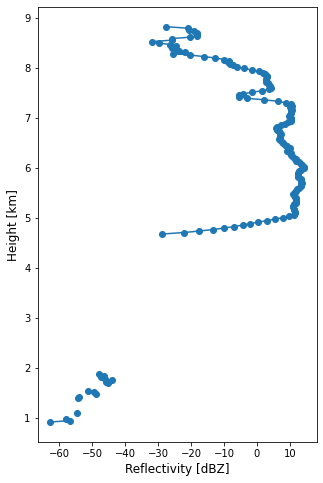

In [12]:
t = 32
#print(dtime)
fig = plt.figure(figsize=[5, 8])
ax1 = plt.subplot()

colormesh = plt.plot(radar['Zh'][t,:], radar['height'][:]/1000, marker='o')

#ttl = ax1.set_title(str(time_serie[1]))
#ttl.set_weight('bold')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
#xlabx.set_style('italic')
xlabx.set_size(12)
#xlaby.set_style('italic')
xlaby.set_size(12)
#ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax1.set_ylabel(r'Height [km]')
ax1.set_xlabel(r'Reflectivity [dBZ]')
#cbar = plt.colorbar(colormesh)
#cbar.set_label(r'Z [dBz]')
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
plt.show()

/home/matheustolen/.conda/envs/matheustolenenv/lib/python3.9/site-packages/matplotlib/colors.py:621: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


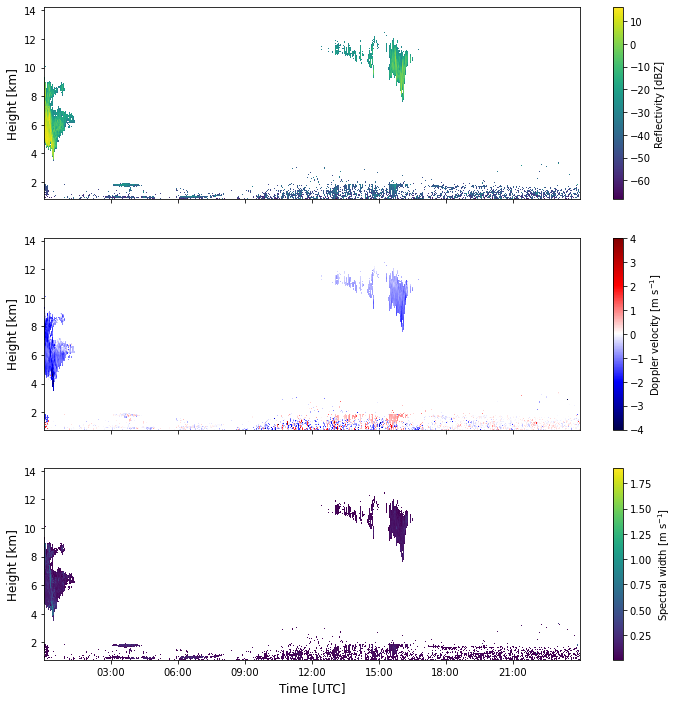

In [13]:
fig, axs = plt.subplots(3, sharex=True, sharey=True, figsize=(12, 12))
#fig.suptitle('Sharing both axes')

f1 = axs[0].pcolormesh(dtime, 
                  radar['height'][:]/1000,
                  np.transpose(radar['Zh'][:]),
                  cmap='viridis',
                  shading='nearest')

axs[0].set_ylabel(r'Height [km]', fontsize = 12.0)
#axs[0].tick_params(axis='y', labelsize=12)
fig.colorbar(f1, ax=axs[0], label='Reflectivity [dBZ]')


f2 = axs[1].pcolormesh(dtime, 
                  radar['height'][:]/1000, 
                  np.transpose(radar['v'][:]),
                  cmap='seismic',
                  shading='nearest',
                  vmin=-4,
                  vmax=4)

axs[1].set_ylabel(r'Height [km]', fontsize = 12.0)
#axs[1].tick_params(axis='y', labelsize=12)
fig.colorbar(f2, ax=axs[1], label='Doppler velocity [m s$^{-1}$]')

f3 = axs[2].pcolormesh(dtime,
                  radar['height'][:]/1000,
                  np.transpose(radar['width'][:]),
                  cmap='viridis',
                  shading='nearest')

axs[2].set_ylabel(r'Height [km]', fontsize = 12.0)
axs[2].set_xlabel(r'Time [UTC]', fontsize = 12.0)
#axs[2].tick_params(axis='y', labelsize=12)
#axs[2].tick_params(axis='x', labelsize=12)
fig.colorbar(f3, ax=axs[2], label='Spectral width [m s$^{-1}$]')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar_z_vd_w.png', dpi=500)
#plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar_z_vd_w.pdf', dpi=400)
plt.show()

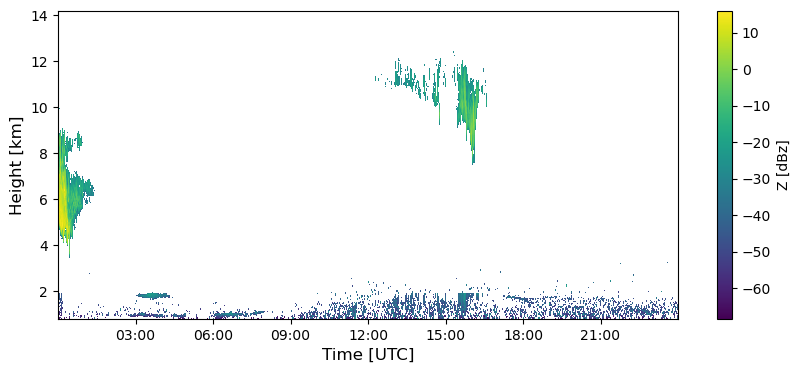

In [7]:
fig = plt.figure(figsize=[10, 4])
ax1 = plt.subplot()

colormesh = plt.pcolormesh(dtime, radar['height'][:]/1000, np.transpose(radar['Zh'][:]),
                          cmap='viridis',
                          shading='nearest')

#ttl = ax1.set_title(str(time_serie[1]))
#ttl.set_weight('bold')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
#xlabx.set_style('italic')
xlabx.set_size(12)
#xlaby.set_style('italic')
xlaby.set_size(12)
#ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax1.set_ylabel(r'Height [km]')
ax1.set_xlabel(r'Time [UTC]')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Z [dBz]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
plt.show()

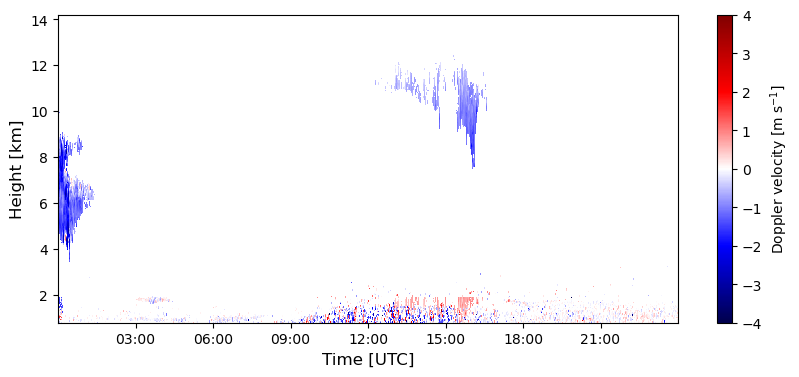

In [8]:
fig = plt.figure(figsize=[10, 4])
ax1 = plt.subplot()

colormesh = plt.pcolormesh(dtime, radar['height'][:]/1000, np.transpose(radar['v'][:]),
                          cmap='seismic',
                          shading='nearest',
                          vmin=-4,
                          vmax=4)

#ttl = ax1.set_title(str(time_serie[1]))
#ttl.set_weight('bold')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
#xlabx.set_style('italic')
xlabx.set_size(12)
#xlaby.set_style('italic')
xlaby.set_size(12)
#ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax1.set_ylabel(r'Height [km]')
ax1.set_xlabel(r'Time [UTC]')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Doppler velocity [m s$^{-1}$]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
plt.show()

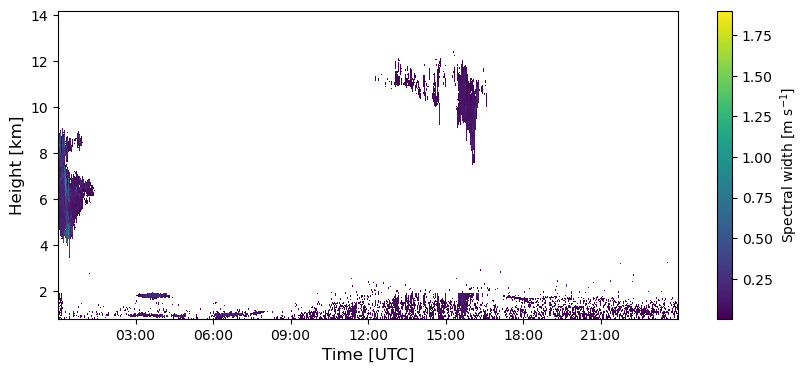

In [9]:
fig = plt.figure(figsize=[10, 4])
ax1 = plt.subplot()

colormesh = plt.pcolormesh(dtime, radar['height'][:]/1000, np.transpose(radar['width'][:]),
                          cmap='viridis',
                          shading='nearest')

#ttl = ax1.set_title(str(time_serie[1]))
#ttl.set_weight('bold')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
#xlabx.set_style('italic')
xlabx.set_size(12)
#xlaby.set_style('italic')
xlaby.set_size(12)
#ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax1.set_ylabel(r'Height [km]')
ax1.set_xlabel(r'Time [UTC]')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Spectral width [m s$^{-1}$]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
plt.show()